**PORTFOLIO ANALYSIS** 


In [1]:
import yfinance as yf 
import numpy as np 
import matplotlib.pyplot as mt #statistical visuals 
import pandas as pd 
import seaborn as sns # advanced vizuals for communicating results 

**IMPORT TECHNICAL ANALYSIS** 

In [4]:
!pip install pandas_ta 

In [2]:
import pandas_ta as pdt

**NOW DOWNLOAD DATA FOR YOUR STOCKS**

In [24]:
tickers_1=["0097.KL","0215.KL","1155.KL","5347.KL","5184.KL","1295.KL","5227.KL","6742.KL","2089.KL"]
print(tickers_1)

['0097.KL', '0215.KL', '1155.KL', '5347.KL', '5184.KL', '1295.KL', '5227.KL', '6742.KL', '2089.KL']


**TICKER                             STOCK NAME                       CATEGORY                          REASON**
0097.Kl                              VITROX                            Growth                       ESG-tech innovator, industry 4.0
0215.KL                              SOLARVEST                         Growth                       ESG-clean energy transition
1155.KL                              MAYBANK                           Defensive                    Strong dividend policy/stable/leadership
5347.KL                              Tenaga National                   Defensive                    leadership in energy sector
5184.KL                              CYPARK                            Wildcard                     ESG- waste to energy 
1295.KL                              Public Bank bhd                   Defensive                    Strong and consistent dividend policy
5227.KL                              IGB REIT                           Growth                      Real Estate champion/ strong dividends 
6742.KL                              YTL POWER                          Growth                      ESG- clean energy transition
2089.KL                              United Plantations                 Defensive                   ESG- sustainable palm oil cultivation



In [25]:
data=yf.download(tickers_1,start="2024-01-01", end="2024-12-31")[["Close"]].dropna()


[*********************100%***********************]  9 of 9 completed


**CHANGE TO DATE_TIME INDEX** 

In [26]:
print(data.index)

DatetimeIndex(['2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
               '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-11',
               '2024-01-12', '2024-01-15',
               ...
               '2024-12-16', '2024-12-17', '2024-12-18', '2024-12-19',
               '2024-12-20', '2024-12-23', '2024-12-24', '2024-12-26',
               '2024-12-27', '2024-12-30'],
              dtype='datetime64[ns]', name='Date', length=246, freq=None)


In [27]:
#COLLAPSE THE PRESENT MULTI_INDEX FORMAT TO ACHEIVE DATA_TIME INDEX FORMAT
data.columns=['_'.join(col) for col in data.columns]

In [28]:
print(data.tail())# stock price towards year end 

            Close_0097.KL  Close_0215.KL  Close_1155.KL  Close_1295.KL  \
Date                                                                     
2024-12-23       3.957227           1.55       9.774546       4.410000   
2024-12-24       3.957227           1.59       9.774546       4.439270   
2024-12-26       4.036970           1.62       9.813334       4.429513   
2024-12-27       4.066873           1.64       9.793940       4.458783   
2024-12-30       4.011983           1.69       9.929697       4.429513   

            Close_2089.KL  Close_5184.KL  Close_5227.KL  Close_5347.KL  \
Date                                                                     
2024-12-23      19.734972           0.85       2.086396      13.731959   
2024-12-24      19.591305           0.85       2.096145      13.810428   
2024-12-26      19.983130           0.86       2.096145      13.908513   
2024-12-27      20.466383           0.86       2.096145      14.457791   
2024-12-30      20.244347           0

In [29]:
print(data.head())    #stock prices at the beginning of the year 

            Close_0097.KL  Close_0215.KL  Close_1155.KL  Close_1295.KL  \
Date                                                                     
2024-01-02       7.108014           1.32       8.154862       3.993975   
2024-01-03       7.157720           1.31       8.127436       3.984644   
2024-01-04       7.157720           1.37       8.255427       4.003307   
2024-01-05       7.098073           1.38       8.282854       4.040634   
2024-01-08       7.117955           1.36       8.282854       4.068629   

            Close_2089.KL  Close_5184.KL  Close_5227.KL  Close_5347.KL  \
Date                                                                     
2024-01-02      11.206603           0.92       1.592226       9.390147   
2024-01-03      11.219153           0.92       1.601429       9.465420   
2024-01-04      11.419944           0.92       1.601429       9.804143   
2024-01-05      11.557987           0.94       1.583022       9.879414   
2024-01-08      11.419944           0

**RETURNS PER STOCK IN 2024**

In [31]:
tickers_1=["Close_0097.KL","Close_0215.KL","Close_1155.KL","Close_1295.KL","Close_2089.KL","Close_5184.KL","Close_5227.KL","Close_6742.KL","Close_5347.KL"]
returns_df=data[tickers_1].pct_change().dropna() #calculates daily returns per stock 
print(returns_df.head())

            Close_0097.KL  Close_0215.KL  Close_1155.KL  Close_1295.KL  \
Date                                                                     
2024-01-03       0.006993      -0.007576      -0.003363      -0.002336   
2024-01-04       0.000000       0.045802       0.015748       0.004684   
2024-01-05      -0.008333       0.007299       0.003322       0.009324   
2024-01-08       0.002801      -0.014493       0.000000       0.006929   
2024-01-09       0.002793       0.000000       0.004415       0.006881   

            Close_2089.KL  Close_5184.KL  Close_5227.KL  Close_6742.KL  \
Date                                                                     
2024-01-03       0.001120       0.000000       0.005780       0.089494   
2024-01-04       0.017897       0.000000       0.000000       0.071429   
2024-01-05       0.012088       0.021739      -0.011494       0.073333   
2024-01-08      -0.011944      -0.042553       0.000000       0.068323   
2024-01-09       0.016484       0.011

**FIXING WEIGHTS TO THE PORTFOLIO**

In [32]:
weights={ "Close_0097.KL":0.20,"Close_0215.KL":0.20,"Close_1155.KL":0.15,"Close_1295.KL":0.06,"Close_2089.KL":0.06,"Close_5184.KL":0.05,"Close_5227.KL":0.06,"Close_6742.KL":0.06,"Close_5347.KL":0.10}
weights_array=np.array([weights[col] for col in returns_df.columns])
portfolio_returns= returns_df.dot(weights_array) 
portfolio_returns #Daily portfolio returns 

Date
2024-01-03    0.005824
2024-01-04    0.020742
2024-01-05    0.007141
2024-01-08   -0.000287
2024-01-09    0.003019
                ...   
2024-12-23   -0.002523
2024-12-24    0.007142
2024-12-26    0.012198
2024-12-27    0.009451
2024-12-30    0.005951
Length: 245, dtype: float64

**PORTFOLIO SIMULATION FOR THE YEAR 2024**

In [33]:
cumulative_return=(1+ portfolio_returns).prod()-1 # tells us how much each RM1 has grown from day one to the last day 
print(f"Each RM1 has grown by {cumulative_return*100}%")

Each RM1 has grown by 17.35197518176197%


In [34]:
annualized_volatility=portfolio_returns.std()*np.sqrt(252) #shows risk over time 
print(f"Risk level at {annualized_volatility*100}%")

Risk level at 17.6221261529893%


In [35]:
risk_free_rate = 0.0371 
excess_return=portfolio_returns.mean()-risk_free_rate 
sharpe_ratio=excess_return/annualized_volatility 
print(f"Risk adjusted rate of return is {sharpe_ratio*100}%")

Risk adjusted rate of return is -20.646461722533925%


In [36]:
portfolio_value=(1 + portfolio_returns).cumprod()
rolling_max= portfolio_value.cummax()
drawdown=portfolio_value/rolling_max-1 
max_drawdown=drawdown.min()      #worst case scenario dip 
print(f"portfolio value is {-max_drawdown*100}% its previous peak")

portfolio value is 10.987712537195915% its previous peak


**VIZUALIZING MY PORTFOLIO** 

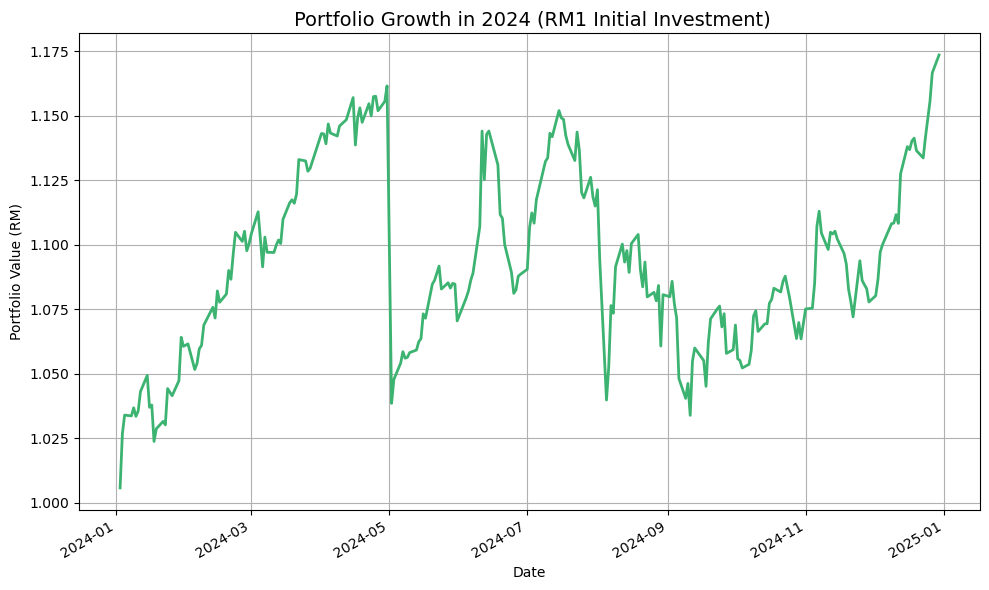

In [37]:
portfolio_value = (1 + portfolio_returns).cumprod()

portfolio_value.plot(figsize=(10, 6), linewidth=2, color='mediumseagreen')
mt.title(" Portfolio Growth in 2024 (RM1 Initial Investment)", fontsize=14)
mt.ylabel("Portfolio Value (RM)")
mt.xlabel("Date")
mt.grid(True)
mt.tight_layout()
mt.show()


Look into zones of extreme dips ( 2024-04 to 05 )
2024-09 to 2025 had significant increase, why?

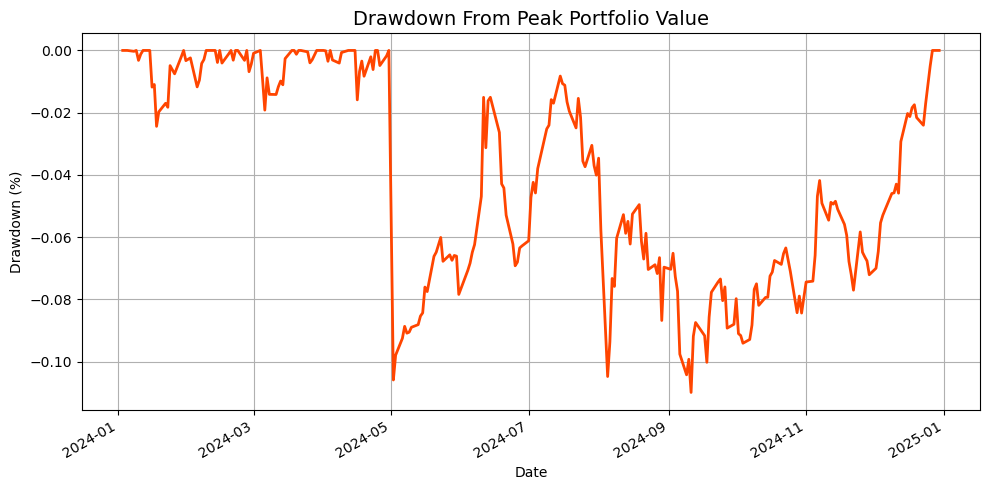

In [38]:
#DRAWDOWN CURVE 
rolling_max = portfolio_value.cummax()
drawdown = portfolio_value / rolling_max - 1

drawdown.plot(figsize=(10, 5), color='orangered', linewidth=2)
mt.title("Drawdown From Peak Portfolio Value", fontsize=14)
mt.ylabel("Drawdown (%)")
mt.grid(True)
mt.tight_layout()
mt.show()


max drawdown occurred in 2024-June. WHY?

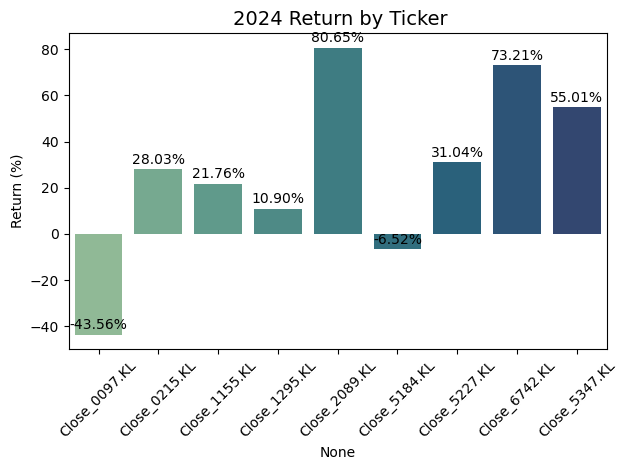

In [39]:
#Cumulative Returns per stock
cumulative_returns = (returns_df + 1).prod() - 1
cumulative_returns *= 100

sns.barplot(x=cumulative_returns.index, y=cumulative_returns.values, palette="crest",hue=cumulative_returns.index,legend=False)
mt.title(" 2024 Return by Ticker", fontsize=14)
mt.ylabel("Return (%)")
mt.xticks(rotation=45)
for idx, value in enumerate(cumulative_returns):
    mt.text(idx, value + 1, f"{value:.2f}%", ha='center', va='bottom')
mt.tight_layout()
mt.show()


Vitrox had the most losses in 2024...discover why and factor that into 2025 decisions.

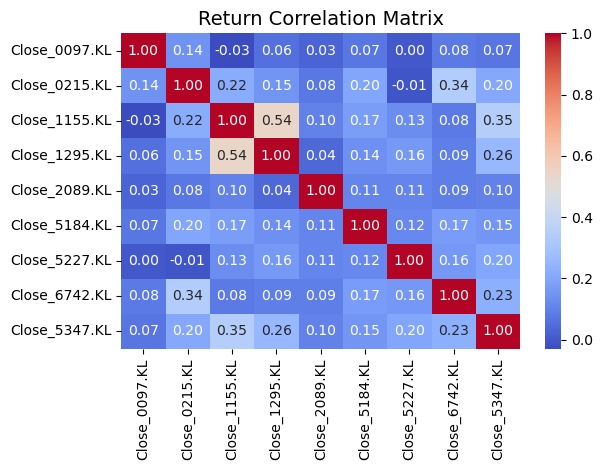

In [40]:
sns.heatmap(returns_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
mt.title("Return Correlation Matrix", fontsize=14)
mt.tight_layout()
mt.show()


shows the relation between any two particular stockjs i.e 0097.Kl and 0215.KL have 0.14 correlation....meaning that when one increases by 1 the other is increasing by approximately 14% .........if correlation is negative then that means when one increases the other drops by that value.

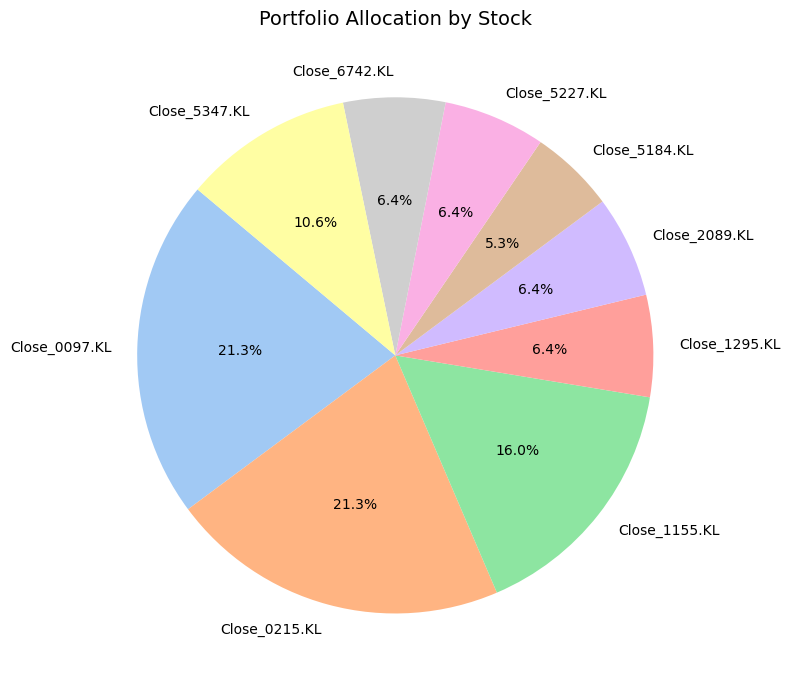

In [41]:
#Portfolio allocation Pie Chart 
labels = list(weights.keys())
sizes = list(weights.values()) 

mt.figure(figsize=(8, 8))
mt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
mt.title("Portfolio Allocation by Stock", fontsize=14)
mt.tight_layout()
mt.show()


**PREDICTIVE MODELLING**

**MY PORTFOLIO IN 2025**

In [3]:
tickers=["0097.KL","0215.KL","1155.KL","5347.KL","5184.KL","1295.KL","5227.KL","6742.KL","2089.KL"]
print(tickers)

['0097.KL', '0215.KL', '1155.KL', '5347.KL', '5184.KL', '1295.KL', '5227.KL', '6742.KL', '2089.KL']


In [8]:
data=yf.download(tickers,start="2025-01-01", end="2025-07-01")[["Close"]].dropna()


[*********************100%***********************]  9 of 9 completed


In [9]:
#COLLAPSE THE PRESENT MULTI_INDEX FORMAT TO ACHEIVE DATA_TIME INDEX FORMAT
data.columns=['_'.join(col) for col in data.columns]

In [10]:
print(data.tail())

            Close_0097.KL  Close_0215.KL  Close_1155.KL  Close_1295.KL  \
Date                                                                     
2025-06-23       3.323359           1.83           9.67           4.42   
2025-06-24       3.383239           1.85           9.80           4.31   
2025-06-25       3.503000           1.98           9.79           4.30   
2025-06-26       3.620000           2.03           9.81           4.34   
2025-06-30       3.520000           2.14           9.70           4.31   

            Close_2089.KL  Close_5184.KL  Close_5227.KL  Close_5347.KL  \
Date                                                                     
2025-06-23      21.719999          0.850           2.30          14.30   
2025-06-24      21.780001          0.880           2.28          14.26   
2025-06-25      21.660000          0.905           2.49          14.24   
2025-06-26      21.700001          0.925           2.48          14.26   
2025-06-30      22.020000          0.

In [11]:
print(data.head())

            Close_0097.KL  Close_0215.KL  Close_1155.KL  Close_1295.KL  \
Date                                                                     
2025-01-02       4.161684           1.70       9.871515       4.429513   
2025-01-03       4.191624           1.72       9.832727       4.390487   
2025-01-06       4.211584           1.71       9.793940       4.400244   
2025-01-07       4.291425           1.71       9.852121       4.400244   
2025-01-08       4.231544           1.71       9.755152       4.341703   

            Close_2089.KL  Close_5184.KL  Close_5227.KL  Close_5347.KL  \
Date                                                                     
2025-01-02      20.205164          0.860       2.096145      14.477408   
2025-01-03      20.244347          0.855       2.096145      14.320472   
2025-01-06      20.231287          0.870       2.135143      14.300855   
2025-01-07      20.218225          0.870       2.144893      14.045832   
2025-01-08      20.492504          0.

In [12]:
tickers=["Close_0097.KL","Close_0215.KL","Close_1155.KL","Close_1295.KL","Close_2089.KL","Close_5184.KL","Close_5227.KL","Close_6742.KL","Close_5347.KL"]
returns_df_2=data[tickers].pct_change().dropna() #calculates daily returns per stock 
print(returns_df_2.head())

            Close_0097.KL  Close_0215.KL  Close_1155.KL  Close_1295.KL  \
Date                                                                     
2025-01-03       0.007194       0.011765      -0.003929      -0.008811   
2025-01-06       0.004762      -0.005814      -0.003945       0.002222   
2025-01-07       0.018958       0.000000       0.005941       0.000000   
2025-01-08      -0.013954       0.000000      -0.009843      -0.013304   
2025-01-09      -0.033019       0.000000       0.001988      -0.002247   

            Close_2089.KL  Close_5184.KL  Close_5227.KL  Close_6742.KL  \
Date                                                                     
2025-01-03       0.001939      -0.005814       0.000000       0.015945   
2025-01-06      -0.000645       0.017544       0.018605      -0.004484   
2025-01-07      -0.000646       0.000000       0.004566       0.013514   
2025-01-08       0.013566      -0.011494       0.000000       0.002222   
2025-01-09      -0.003824      -0.029

In [13]:
weights={ "Close_0097.KL":0.20,"Close_0215.KL":0.20,"Close_1155.KL":0.15,"Close_1295.KL":0.06,"Close_2089.KL":0.06,"Close_5184.KL":0.05,"Close_5227.KL":0.06,"Close_6742.KL":0.06,"Close_5347.KL":0.10}
weights_array=np.array([weights[col] for col in returns_df_2.columns])
portfolio_returns= returns_df_2.dot(weights_array) 
portfolio_returns #Daily portfolio returns 

Date
2025-01-03    0.002372
2025-01-06    0.000880
2025-01-07    0.003945
2025-01-08   -0.004693
2025-01-09   -0.013917
                ...   
2025-06-23    0.001408
2025-06-24    0.007442
2025-06-25    0.028984
2025-06-26    0.016954
2025-06-30    0.007354
Length: 117, dtype: float64

In [14]:
cumulative_return=(1+ portfolio_returns).prod()-1 # tells us how much each RM1 has grown from day one to the last day 
print(f"Each RM1 has grown by {cumulative_return*100}%")

Each RM1 has grown by 4.074962428665518%


In [15]:
annualized_volatility=portfolio_returns.std()*np.sqrt(252) #shows risk over time 
print(f"Risk level at {annualized_volatility*100}%")

Risk level at 21.080271250897496%


In [16]:
risk_free_rate = 0.0342
excess_return=portfolio_returns.mean()-risk_free_rate 
sharpe_ratio=excess_return/annualized_volatility 
print(f"Risk adjusted rate of return is {sharpe_ratio*100}%")

Risk adjusted rate of return is -16.020121061282115%


In [18]:
portfolio_value=(1 + portfolio_returns).cumprod()
rolling_max= portfolio_value.cummax()
drawdown=portfolio_value/rolling_max-1 
max_drawdown=drawdown.min()      #worst case scenario dip 
print(f"portfolio value is {-max_drawdown*100}% below its previous peak")

portfolio value is 17.56143972039197% below its previous peak


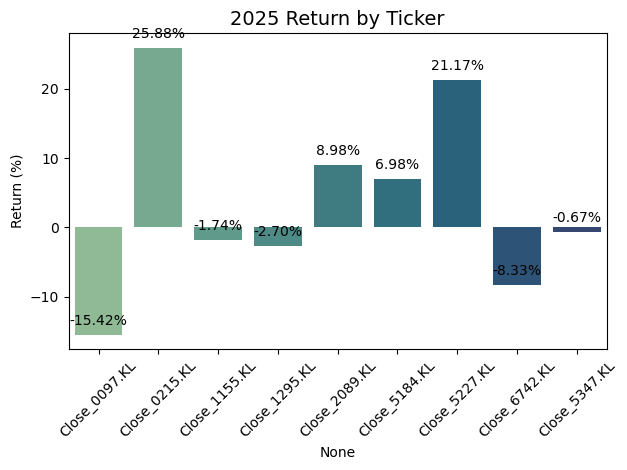

In [20]:
#Cumulative Returns per stock
cumulative_returns_2 = (returns_df_2 + 1).prod() - 1
cumulative_returns_2 *= 100

sns.barplot(x=cumulative_returns_2.index, y=cumulative_returns_2.values, palette="crest",hue=cumulative_returns_2.index,legend=False)
mt.title("2025 Return by Ticker", fontsize=14)
mt.ylabel("Return (%)")
mt.xticks(rotation=45)
for idx, value in enumerate(cumulative_returns_2):
    mt.text(idx, value + 1, f"{value:.2f}%", ha='center', va='bottom')
mt.tight_layout()
mt.show()


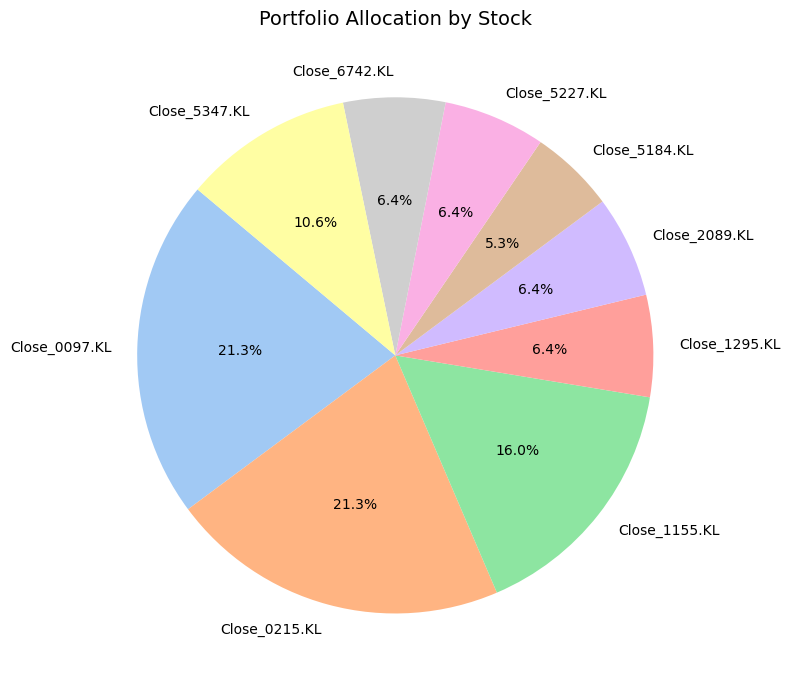

In [21]:
#Portfolio allocation Pie Chart 
labels = list(weights.keys())
sizes = list(weights.values()) 

mt.figure(figsize=(8, 8))
mt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
mt.title("Portfolio Allocation by Stock", fontsize=14)
mt.tight_layout()
mt.show()


Text(0.5, 1.0, '2024 vs 2025 RETURNS PERFOMANCE')

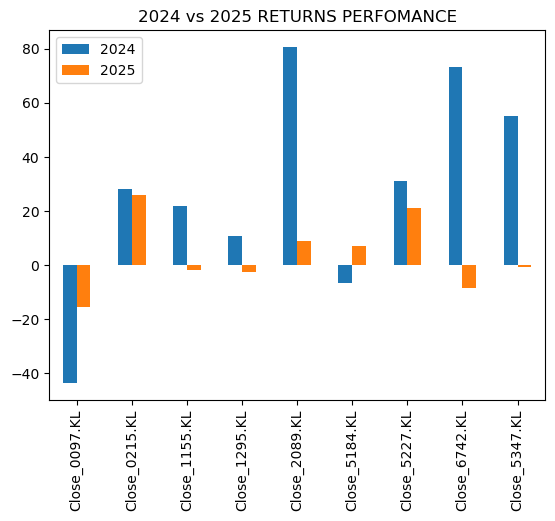

In [42]:
comparison_df = pd.DataFrame({                                      #cumulative_returns reps returns in 2024 #cr2 for 2025
    "2024": cumulative_returns,
    "2025": cumulative_returns_2
})
comparison_df.plot(kind="bar")
mt.title("2024 vs 2025 RETURNS PERFOMANCE")

**REBALANCING THE PORTFOLIO**

**SETTING UP THE RULES**

**FURTHER INSPECTION-2023 PERFOMANCE**

follow same codes as 2024 section.....just make sure you download 2023 data from yfinance 

**INDIVIDUAL STOCK ANALYSIS-ESPECIALLY THOSE WITH SERIOUS EFFECTS TO THE PORTFOLIO**

**VITROX STOCK 0097.KL** 

**YTL POWER 6742.KL**